# Emotion Classification in texts using LSTM and Word2Vec
## Architecture:
(X) Text -> Embedding (W2V pretrained on wikipedia articles) -> Deep Network (LSTM/GRU) -> Fully connected (Dense) -> Output Layer (Softmax) -> Emotion class (Y)

## Embedding Layer
Word Embedding is a representation of text where words that have the similar meaning have a similar representation. We will use 300 dimentional word vectors pre-trained on wikipedia articles. We can also train the w2v model with our data, however our dataset is quite small and trained word vectors might not be as good as using pretrained w2v.
## Deep Network
Deep network takes the sequence of embedding vectors as input and converts them to a compressed representation. The compressed representation effectively captures all the information in the sequence of words in the text. The deep network part is usually an RNN or some forms of it like LSTM/GRU. The dropout can be added to overcome the tendency to overfit, a very common problem with RNN based networks.
## Fully Connected Layer
The fully connected layer takes the deep representation from the RNN/LSTM/GRU and transforms it into the final output classes or class scores. This component is comprised of fully connected layers along with batch normalization and optionally dropout layers for regularization.
## Output Layer
Based on the problem at hand, this layer can have either Sigmoid for binary classification or Softmax for both binary and multi classification output.

# Workflow:
- 1. Import Data
- 2. Prepare the input data
- 3. Import pre-trained W2V
- 4. Create Neural Network Pipeline
- 5. Train The Model
- 6. Evaluate results

## 1. Import Data  

In [ ]:
import pandas as pd
import numpy as np

# text preprocessing
from nltk.tokenize import word_tokenize
import re

# plots and metrics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# preparing input to our model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# keras layers
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout

Defining vector space dimension and fixed input size

In [ ]:
# Number of Labels : joy, anger, fear, sadness, neutral
num_classes = 5

# Number of dimensions for word embedding
embed_num_dims = 300

# Max input length (max number of words)
max_seq_len = 500

class_names = ['joy', 'fear', 'anger', 'sadness', 'neutral']

In [ ]:
train_data = pd.read_csv('data_train.csv')
test_data = pd.read_csv('data_test.csv')

X_train = train_data.Text
X_test = test_data.Text

y_train = train_data.Emotion
y_test = test_data.Emotion

data = pd.concat([train_data, test_data])

print(data.Emotion.value_counts())


Emotion
joy        2326
sadness    2317
anger      2259
neutral    2254
fear       2171
Name: count, dtype: int64


In [ ]:
data.head()

,Emotion,Text
0,neutral,There are tons of other paintings that I thin...
1,sadness,"Yet the dog had grown old and less capable , a..."
2,fear,When I get into the tube or the train without ...
3,fear,This last may be a source of considerable disq...
4,anger,She disliked the intimacy he showed towards so...


# Text Preprocessing

In [ ]:
import nltk
nltk.download('punkt_tab')
def clean_text(data):

    # remove hashtags and @usernames
    data = re.sub(r"(#[\d\w\.]+)", '', data)
    data = re.sub(r"(@[\d\w\.]+)", '', data)

    # tekenization using nltk
    data = word_tokenize(data)

    return data

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


*Making things easier for keras tokenizer

---



In [ ]:
texts = [' '.join(clean_text(text)) for text in data.Text]

texts_train = [' '.join(clean_text(text)) for text in X_train]
texts_test = [' '.join(clean_text(text)) for text in X_test]

In [ ]:
texts_train[1]

'Yet the dog had grown old and less capable , and one day the gillie had come and explained with great sorrow that the dog had suffered a stroke , and must be put down .'

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequence_train = tokenizer.texts_to_sequences(texts_train)
sequence_test = tokenizer.texts_to_sequences(texts_test)

index_of_words = tokenizer.word_index

# Vocab size is the number of unique words + 0 reserved to padding
vocab_size = len(index_of_words) + 1

print(f"Number of unique words: : {vocab_size}")

Number of unique words: : 12088


In [ ]:
X_train_pad = pad_sequences(sequence_train, maxlen = max_seq_len )
X_test_pad = pad_sequences(sequence_test, maxlen = max_seq_len )

X_train_pad

array([[    0,     0,     0, ...,   119,    51,   345],
       [    0,     0,     0, ...,    37,   277,   154],
       [    0,     0,     0, ...,    16,     2,  1210],
       ...,
       [    0,     0,     0, ...,   876,     4,   909],
       [    0,     0,     0, ...,     1,     6,   117],
       [    0,     0,     0, ..., 10258,   173,    13]], dtype=int32)

Categorize labels:

In [ ]:
encoding = {
    'joy': 0,
    'fear': 1,
    'anger': 2,
    'sadness': 3,
    'neutral': 4
}

# Integer labels
y_train = [encoding[x] for x in train_data.Emotion]
y_test = [encoding[x] for x in test_data.Emotion]

print(y_train[:5])

[4, 3, 1, 1, 2]


In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

y_train

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

# 2. Import pretrained word vectors

- Importing pretrained word2vec from file and creating embedding matrix
- We will later map each word in our corpus to existing word vector

In [ ]:
def create_embedding_matrix(filepath, word_index, embedding_dim):
    vocab_size = len(word_index) + 1  # Adding again 1 because of reserved 0 index
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    with open(filepath) as f:
        for line in f:
            word, *vector = line.split()
            if word in word_index:
                idx = word_index[word]
                embedding_matrix[idx] = np.array(
                    vector, dtype=np.float32)[:embedding_dim]
    return embedding_matrix

In [ ]:
import urllib.request
import zipfile
import os

fname = 'embeddings/wiki-news-300d-1M-subword.vec'

if not os.path.isfile(fname):
    print('Downloading word vectors...')


    urllib.request.urlretrieve(
        'https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M-subword.vec.zip',
        'wiki-news-300d-1M-subword.vec.zip'
    )

    print('Unzipping...')
    with zipfile.ZipFile('wiki-news-300d-1M-subword.vec.zip', 'r') as zip_ref:
        zip_ref.extractall('embeddings')

    print('done.')

    os.remove('wiki-news-300d-1M-subword.vec.zip')

In [ ]:
embedded_matrix = create_embedding_matrix(fname, index_of_words, embedding_dim=300)
print(embedded_matrix.shape)

(12088, 300)


Some of the words from our corpus were not included in the pre-trained word vectors. If we inspect those words we'll see that it's mostly spelling errors. It's also good to double check the noise in our data f.e different languages or tokenizer errors.

In [ ]:
# Inspect unseen words
new_words = 0

for word in index_of_words:
    entry = embedded_matrix[index_of_words[word]]
    if all(v == 0 for v in entry):
        new_words = new_words + 1

print('Words found in wiki vocab: ' + str(len(index_of_words) - new_words))
print('New words found: ' + str(new_words))

Words found in wiki vocab: 11133
New words found: 954


## 3. Create LSTM Pipeline

## Embedding Layer
We will use pre-trained word vectors. We could also train our own embedding layer if we don't specify the pre-trained weights

-  **vocabulary size**:
 the maximum number of terms that are used to represent a text: e.g. if we set the size of the “vocabulary” to 1000 only the first thousand terms most frequent in the corpus will be considered (and the other terms will be ignored)
-  **the maximum length**:
 of the texts (which must all be the same length)
- **size of embeddings**:
 basically, the more dimensions we have the more precise the semantics will be, but beyond a certain threshold we will lose the ability of the embedding to define a coherent and general enough semantic area
- **trainable**:
 True if you want to fine-tune them while training

In [ ]:
embedd_layer = Embedding(
    vocab_size,
    embed_num_dims,
    input_length = max_seq_len,
    weights = [embedded_matrix],
    trainable = False
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Model Pipeline
- **the input** is the first N words of each text (with proper padding)
- **the first level** creates embedding of words, using vocabulary with a certain dimension, and a given size of embeddings
- **LSTM/GRU** layer which will receive word embeddings for each token in the tweet as inputs. The intuition is that its output tokens will store information not only of the initial token, but also any previous tokens; In other words, the LSTM layer is generating a new encoding for the original input.
- **the output** level has a number of neurons equal to the classes of the problem and a “softmax” activation function
You can change GRU to LSTM. The results will be very similar but LSTM might take longer to train.

In [ ]:
# Parameters
gru_output_size = 128
bidirectional = True

# Embedding Layer, LSTM or biLSTM, Dense, softmax
model = Sequential()
model.add(embedd_layer)

if bidirectional:
    model.add(Bidirectional(GRU(units=gru_output_size,
                              dropout=0.2,
                              recurrent_dropout=0.2)))
else:
     model.add(GRU(units=gru_output_size,
                dropout=0.2,
                recurrent_dropout=0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.build(input_shape=(None, max_seq_len))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 300)       │     3,626,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,973,413 (15.16 MB)

 Trainable params: 347,013 (1.32 MB)

 Non-trainable params: 3,626,400 (13.83 MB)

In [19]:
batch_size = 128
epochs = 20

hist = model.fit(X_train_pad, y_train,
                 batch_size=batch_size,
                 epochs=epochs,
                 validation_data=(X_test_pad,y_test))

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.3257 - loss: 1.4821 - val_accuracy: 0.3787 - val_loss: 1.3911
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.3719 - loss: 1.3682 - val_accuracy: 0.3896 - val_loss: 1.3509
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.4219 - loss: 1.3099 - val_accuracy: 0.4630 - val_loss: 1.2853
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.4764 - loss: 1.2427 - val_accuracy: 0.5246 - val_loss: 1.2081
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.5297 - loss: 1.1764 - val_accuracy: 0.5753 - val_loss: 1.1068
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.5616 - loss: 1.1045 - val_accuracy: 0.6015 - val_loss: 1.0549
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.5902 - loss: 1.0532 - val_accuracy: 0.6275 - val_loss: 1.0136
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.6117 - loss: 1.0152 - val_accuracy: 0.6260 - v

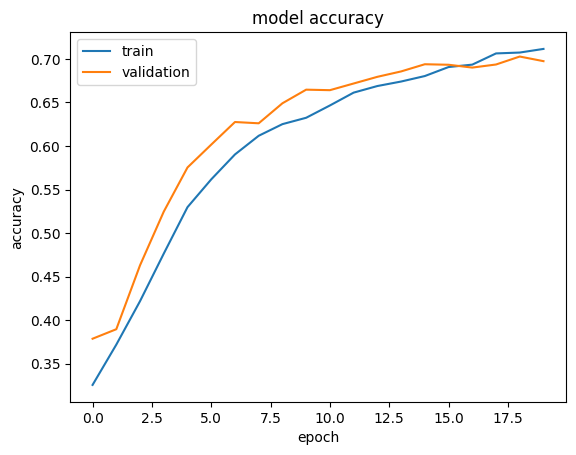

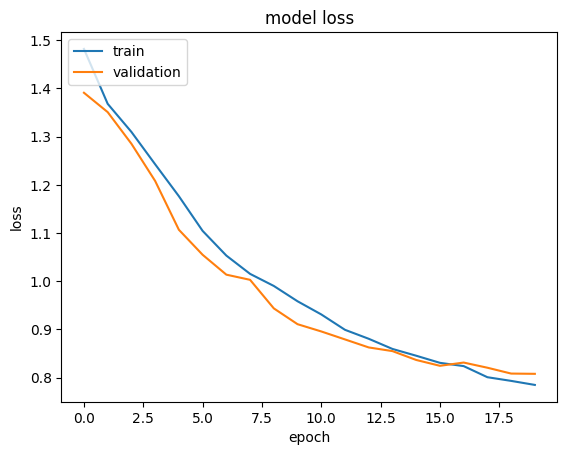

In [20]:
#  Accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# Loss
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# 4. Evaluation

In [21]:
predictions = model.predict(X_test_pad)
predictions = np.argmax(predictions, axis=1)
predictions = [class_names[pred] for pred in predictions]

107/107 ━━━━━━━━━━━━━━━━━━━━ 60s 555ms/step


In [ ]:
print("Accuracy: {:.2f}%".format(accuracy_score(test_data.Emotion, predictions) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(test_data.Emotion, predictions, average='micro') * 100))

Lets try other inputs:

In [ ]:
print('Message: {}\nPredicted: {}'.format(X_test[4], predictions[4]))

In [24]:
import time

message = ['i broke up with my girlfriend']

seq = tokenizer.texts_to_sequences(message)
padded = pad_sequences(seq, maxlen=max_seq_len)

start_time = time.time()
pred = model.predict(padded)

print('Message: ' + str(message))
print('predicted: {} ({:.2f} seconds)'.format(class_names[np.argmax(pred)], (time.time() - start_time)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
Message: ['i broke up with my girlfriend']
predicted: sadness (0.57 seconds)
